# Passive compliance — guitar

How the hand's **torsional (joint-space) spring stiffness** shapes the interaction
when the closed fingers drag across the guitar strings.  Audio intensity is captured
externally via the camera microphone.  This notebook shows the **joint angle** and
**torque** state logged by the control loop during each sweep, as a sanity check
that the fingers were correctly closed and the springs were active.

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('../../'))
from hand_config import (
    TORSIONAL_SPRINGS,
    GUITAR_N_RUNS          as N_RUNS,
    GUITAR_INDEX,
    GUITAR_CLOSED_FINGERS  as CLOSED_FINGERS,
)

from plot_config import COLORS, FIG_W_SINGLE, FIG_W_DOUBLE  # style auto-applied

FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
OUTPUT = os.path.join('outputs', 'guitar_playing_hand')
os.makedirs(OUTPUT, exist_ok=True)

# Motor indices for the four closed fingers (MCP, PIP)
# index=5,6  middle=7,8  ring=9,10  pinky=11,12
FINGER_MOTOR_IDX = {'index': [5, 6], 'middle': [7, 8], 'ring': [9, 10], 'pinky': [11, 12]}

def _synth(ktors):
    """Synthetic demo dataset (same schema as the real CSV)."""
    rng  = np.random.default_rng(int(ktors * 100))
    rows = []
    cols = ([f'q_{i}' for i in range(13)] +
            [f'qdot_{i}' for i in range(13)] +
            [f'tau_{i}' for i in range(13)])
    t = 0.0; dt = 0.02
    for run in range(1, N_RUNS + 1):
        for phase, length in [('sweep', 2.0), ('lift', 0.5), ('return', 0.5), ('descend', 0.5)]:
            n = int(length / dt)
            for _ in range(n):
                q   = np.zeros(13)
                tau = np.zeros(13)
                for f, idxs in FINGER_MOTOR_IDX.items():
                    for j in idxs:
                        q[j]   = GUITAR_INDEX[0] + rng.normal(0, 0.003)
                        tau[j] = ktors * 0.05 + rng.normal(0, 0.002)
                row = {'time_s': f'{t:.4f}', 'k_torsional': ktors, 'run': run, 'phase': phase}
                row.update({c: f'{v:.5f}' for c, v in zip(cols, list(q) + [0.0]*13 + list(tau))})
                rows.append(row); t += dt
        t += 0.3
    return pd.DataFrame(rows)

DEMO = False
def load(ktors):
    global DEMO
    path = os.path.join(OUTPUT, f'data_K{ktors:.2f}.csv')
    if os.path.isfile(path):
        return pd.read_csv(path)
    DEMO = True
    return _synth(ktors)

DATA = {k: load(k) for k in TORSIONAL_SPRINGS}
banner = ' DEMO (synthetic) data ' if DEMO else ' measured data '
print(f'Loaded{banner}|  K levels: {TORSIONAL_SPRINGS}')

Loaded measured data |  K levels: [0.05, 0.2, 0.6]


## Audio intensity (RMS envelope)

RMS energy of the cleaned guitar recording over time — shows when strums happen
as clear peaks above the UR5 background baseline.
Adjust `T_START` and `T_END` (seconds) to trim the region of interest.

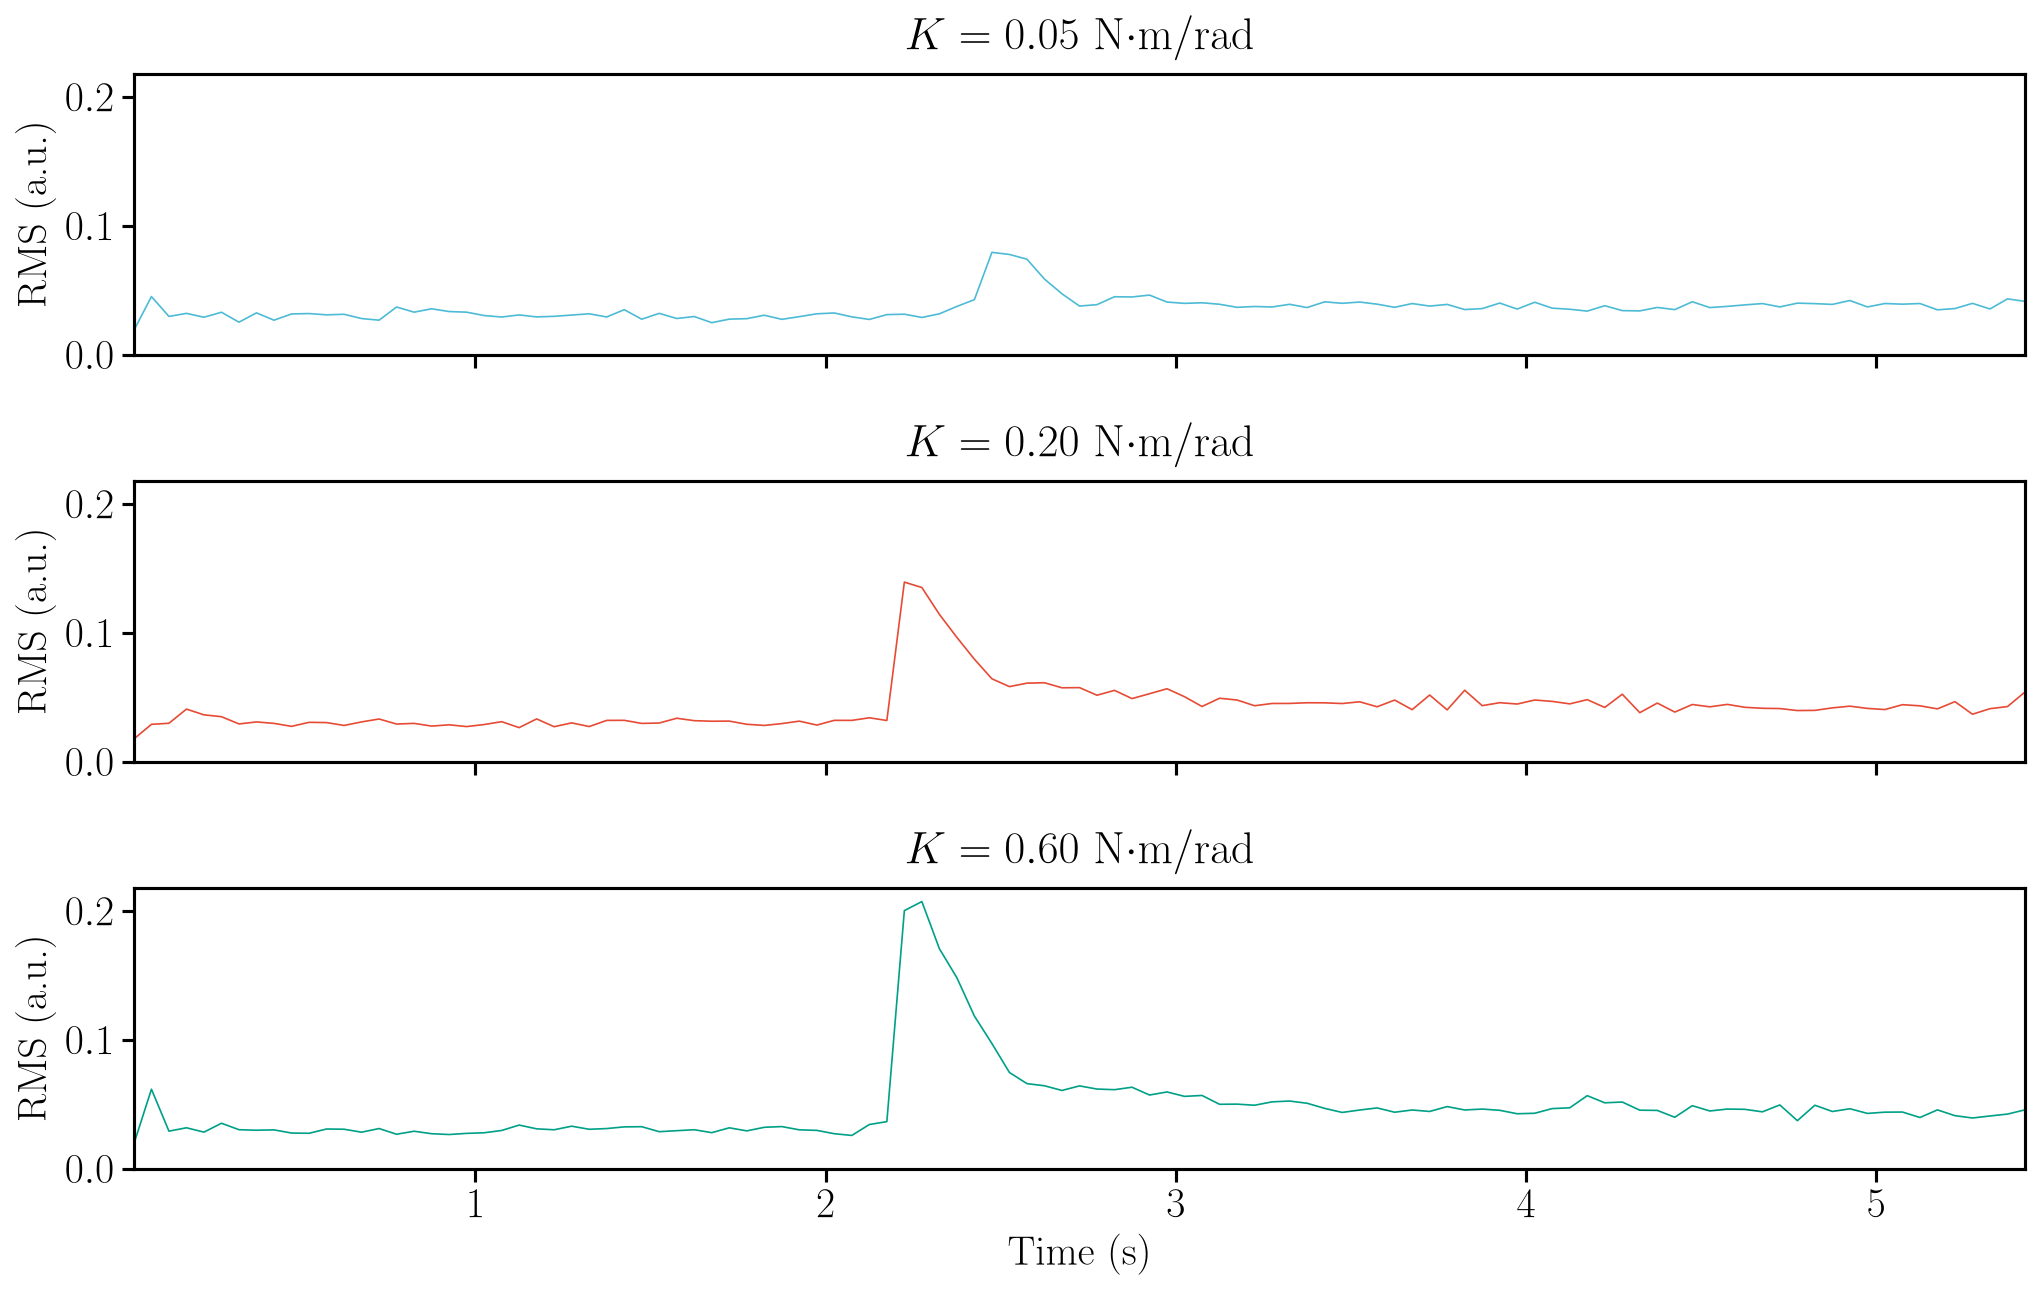

In [4]:
import soundfile as sf

# ── One audio file per stiffness condition (set paths to None to skip) ─────────
AUDIO_DIR = 'AudioExtraction'
AUDIO_FILES = {
    TORSIONAL_SPRINGS[0]: os.path.join(AUDIO_DIR, 'GUITAR_K1.wav'),
    TORSIONAL_SPRINGS[1]: os.path.join(AUDIO_DIR, 'GUITAR_K2.wav'),
    TORSIONAL_SPRINGS[2]: os.path.join(AUDIO_DIR, 'GUITAR_K3.wav'),
}

# ── Time window (seconds). Set to None for full recording. ────────────────────
T_START = None
T_END   = None

# ── RMS window length ─────────────────────────────────────────────────────────
RMS_MS = 50   # ms

def _rms_envelope(audio, sr):
    win      = max(1, int(RMS_MS * sr / 1000))
    n_frames = len(audio) // win
    rms      = np.sqrt(np.mean(audio[:n_frames * win].reshape(n_frames, win) ** 2, axis=1))
    t        = (np.arange(n_frames) * win + win / 2) / sr
    return t, rms

available = {k: p for k, p in AUDIO_FILES.items() if os.path.isfile(p)}
missing   = [p for p in AUDIO_FILES.values() if not os.path.isfile(p)]
if missing:
    for p in missing:
        print(f'  [missing] {p}')

if available:
    # Pre-load all RMS data to find the global y-axis maximum
    rms_data = {}
    for k, path in available.items():
        audio, sr = sf.read(path)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        t_full = np.arange(len(audio)) / sr
        mask = np.ones(len(t_full), dtype=bool)
        if T_START is not None: mask &= t_full >= T_START
        if T_END   is not None: mask &= t_full <= T_END
        t_rms, rms = _rms_envelope(audio[mask], sr)
        if T_START is not None:
            t_rms += T_START
        rms_data[k] = (t_rms, rms, path)

    rms_max = max(v[1].max() for v in rms_data.values())

    fig, axes = plt.subplots(len(available), 1,
                             figsize=(14, 3 * len(available)),
                             sharex=True, squeeze=False)
    for ax, (k, (t_rms, rms, _)) in zip(axes[:, 0], rms_data.items()):
        col = COLORS[TORSIONAL_SPRINGS.index(k) % len(COLORS)]
        ax.plot(t_rms, rms, lw=0.8, color=col)
        ax.set_ylabel('RMS (a.u.)')
        ax.set_title(rf'$K = {k:.2f}$ N$\cdot$m/rad')
        ax.set_xlim(t_rms[0], t_rms[-1])
        ax.set_ylim(0, rms_max * 1.05)

    axes[-1, 0].set_xlabel('Time (s)')
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT, 'guitar_audio_rms.pdf'))
    plt.show()
else:
    print('No audio files found. Run AudioExtraction/extract_audio.py for each take.')